In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

np.random.seed(42)

print("Imports ready")

Imports ready


In [3]:
import pandas as pd
import numpy as np

# --- Build a 5-year daily date range ---
# Prophet works best with daily data
# We simulate from Jan 2020 to Dec 2024 — covers COVID bump, recovery, normalisation
dates = pd.date_range(start="2020-01-01", end="2024-12-31", freq="D")

# --- Build the yearly seasonality curve ---
# day_of_year goes from 0 to 1 across the year (0 = Jan 1, 1 = Dec 31)
# This lets us apply sine/cosine waves that repeat every year
day_of_year = dates.day_of_year / 365.0

# Base seasonality: peaks in Dec (day ~335-365), dips in Jan-Feb
# np.cos with a phase shift puts the peak at end of year
yearly_seasonality = (
    30 * np.cos(2 * np.pi * (day_of_year - 0.92))   # primary Dec peak
    + 10 * np.cos(4 * np.pi * (day_of_year - 0.55))  # secondary Jul/Aug bump
)

# --- Build weekly rhythm ---
# Online shopping spikes on weekends (Sat/Sun)
# dayofweek: 0=Monday, 6=Sunday
weekly_bump = np.where(dates.dayofweek >= 5, 8, 0)  # +8 points on weekends

# --- COVID effect: Mar 2020 to Aug 2020 ---
# Lockdowns drove a massive online shopping surge — real, not fictional
covid_bump = np.where(
    (dates >= "2020-03-15") & (dates <= "2020-08-31"),
    25, 0
)

# --- Assemble the base signal ---
# Start at a baseline of 55 (Google Trends midpoint for an established keyword)
# Add all layers together, then clip between 0 and 100 (Trends scale)
base_signal = 55 + yearly_seasonality + weekly_bump + covid_bump

# Add realistic noise — no real signal is perfectly smooth
np.random.seed(42)  # same seed as Cell 1 — keeps everything reproducible
noise = np.random.normal(loc=0, scale=4, size=len(dates))

search_interest = np.clip(base_signal + noise, 0, 100).astype(int)

# --- Build the DataFrame ---
trends_df = pd.DataFrame({
    'date': dates,
    'search_interest': search_interest
})

print("Shape:", trends_df.shape)
print("\nDate range:", trends_df['date'].min(), "to", trends_df['date'].max())
print("\nSample data:")
trends_df.head(10)

Shape: (1827, 2)

Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00

Sample data:


,date,search_interest
0,2020-01-01,91
1,2020-01-02,88
2,2020-01-03,91
3,2020-01-04,100
4,2020-01-05,95
5,2020-01-06,87
6,2020-01-07,94
7,2020-01-08,91
8,2020-01-09,86
9,2020-01-10,90


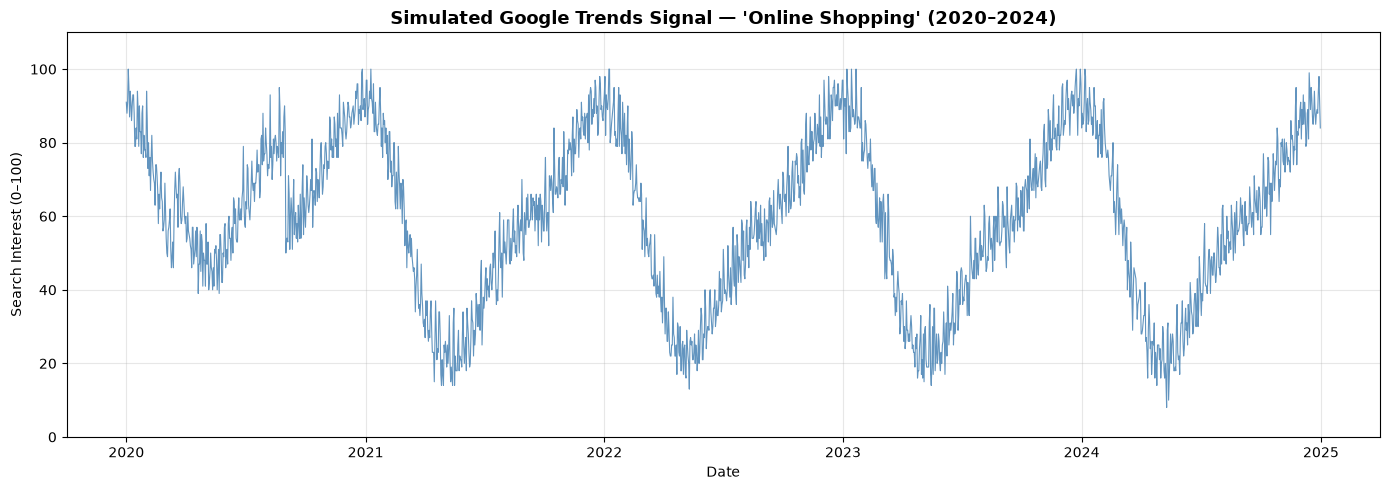

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(trends_df['date'], trends_df['search_interest'],
        color='steelblue', linewidth=0.8, alpha=0.85)

# Formatting the x-axis to show year labels cleanly
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title("Simulated Google Trends Signal — 'Online Shopping' (2020–2024)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Search Interest (0–100)")
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# --- Rescale search_interest to a realistic 40-85 range ---
# Raw signal goes 10-100 which is too extreme
# Real "online shopping" interest stays between ~40 (slow months) and ~85 (festive peak)
scaled_interest = 40 + (trends_df['search_interest'] - trends_df['search_interest'].min()) / \
                      (trends_df['search_interest'].max() - trends_df['search_interest'].min()) * 45

# --- Build Sessions ---
# Base: 8000 sessions/day for a mid-size ecommerce business
# Sessions scale proportionally with search interest — more people searching = more arriving
sessions = (8000 + scaled_interest * 120 + 
            np.random.normal(0, 400, len(dates))).astype(int)
sessions = np.clip(sessions, 1000, 25000)  # no negatives, cap outliers

# --- Build Conversion Rate ---
# Typical ecommerce CVR: 2-4%
# Slight positive correlation with interest (high-intent searches convert better)
# But mostly stable — CVR doesn't swing wildly day to day
conversion_rate = np.clip(
    0.028 + (scaled_interest - 60) * 0.0003 + 
    np.random.normal(0, 0.004, len(dates)),
    0.005, 0.08
).round(4)

# --- Build Revenue ---
# Revenue = sessions × CVR × average order value
# AOV varies slightly day to day (different product mixes, discount days)
aov = np.random.normal(loc=65, scale=8, size=len(dates))  # avg order ~$65
revenue = (sessions * conversion_rate * aov).round(2)

# --- Build Channel ---
# Each session came from somewhere — Organic, Paid, or Direct
# Weights reflect a realistic ecommerce split
channel = np.random.choice(
    ['Organic', 'Paid', 'Direct'],
    size=len(dates),
    p=[0.45, 0.35, 0.20]
)

# --- Assemble the full DataFrame ---
marketing_df = pd.DataFrame({
    'date': dates,
    'search_interest': scaled_interest.round(1),
    'sessions': sessions,
    'conversion_rate': conversion_rate,
    'revenue': revenue,
    'channel': channel
})

print("Shape:", marketing_df.shape)
print("\nColumn types:")
print(marketing_df.dtypes)
print("\nSample data:")
marketing_df.head(10)

Shape: (1827, 6)

Column types:
date               datetime64[us]
search_interest           float64
sessions                    int64
conversion_rate           float64
revenue                   float64
channel                       str
dtype: object

Sample data:


,date,search_interest,sessions,conversion_rate,revenue,channel
0,2020-01-01,80.6,18236,0.0348,43537.55,Direct
1,2020-01-02,79.1,17456,0.0352,40346.21,Organic
2,2020-01-03,80.6,17679,0.0342,39478.33,Organic
3,2020-01-04,85.0,18483,0.0272,23088.50,Organic
4,2020-01-05,82.6,17999,0.0354,45213.97,Organic
5,2020-01-06,78.6,17818,0.0424,49917.29,Organic
6,2020-01-07,82.1,17962,0.0332,40805.49,Organic
7,2020-01-08,80.6,17426,0.0313,32348.75,Paid
8,2020-01-09,78.2,17522,0.0349,37867.84,Paid
9,2020-01-10,80.1,17155,0.0353,37370.91,Organic


In [6]:
# We're injecting 3 anomalies into a COPY of the DataFrame
# Never modify the original — always work on a copy so you can compare before/after
df = marketing_df.copy()

# --- Anomaly 1: Organic Traffic Drop ---
# What it mimics: Google core algorithm update tanks organic rankings overnight
# When: 3 weeks in June 2022 — a realistic timing for algo updates
# Effect: sessions drop 60% for those dates
anomaly1_mask = (df['date'] >= '2022-06-10') & (df['date'] <= '2022-06-30')
df.loc[anomaly1_mask, 'sessions'] = (df.loc[anomaly1_mask, 'sessions'] * 0.40).astype(int)

# --- Anomaly 2: Conversion Rate Spike ---
# What it mimics: A viral moment or highly successful A/B test
# When: 5 days in November 2023 — right before festive peak, realistic timing
# Effect: CVR jumps to 3x normal
anomaly2_mask = (df['date'] >= '2023-11-20') & (df['date'] <= '2023-11-25')
df.loc[anomaly2_mask, 'conversion_rate'] = (
    df.loc[anomaly2_mask, 'conversion_rate'] * 3.0
).round(4)

# Recalculate revenue for those days — it changes because CVR changed
df.loc[anomaly2_mask, 'revenue'] = (
    df.loc[anomaly2_mask, 'sessions'] *
    df.loc[anomaly2_mask, 'conversion_rate'] *
    65  # AOV stays constant
).round(2)

# --- Anomaly 3: Session Spike with Normal Conversions ---
# What it mimics: Bot traffic or a tracking pixel misfiring
# Sessions balloon but nobody actually buys — CVR collapses proportionally
# When: 4 days in March 2024
anomaly3_mask = (df['date'] >= '2024-03-15') & (df['date'] <= '2024-03-18')
df.loc[anomaly3_mask, 'sessions'] = (df.loc[anomaly3_mask, 'sessions'] * 4.0).astype(int)
df.loc[anomaly3_mask, 'conversion_rate'] = (
    df.loc[anomaly3_mask, 'conversion_rate'] * 0.25
).round(4)

# Recalculate revenue — high sessions + collapsed CVR = roughly normal revenue
# This is the signature of bot traffic: volume without value
df.loc[anomaly3_mask, 'revenue'] = (
    df.loc[anomaly3_mask, 'sessions'] *
    df.loc[anomaly3_mask, 'conversion_rate'] *
    65
).round(2)

# --- Verify all 3 anomalies were injected ---
print("=== Anomaly 1: Organic Drop (June 2022) ===")
print(df[anomaly1_mask][['date', 'sessions', 'conversion_rate', 'revenue']].head(5))

print("\n=== Anomaly 2: CVR Spike (Nov 2023) ===")
print(df[anomaly2_mask][['date', 'sessions', 'conversion_rate', 'revenue']])

print("\n=== Anomaly 3: Bot Traffic (Mar 2024) ===")
print(df[anomaly3_mask][['date', 'sessions', 'conversion_rate', 'revenue']])

=== Anomaly 1: Organic Drop (June 2022) ===
          date  sessions  conversion_rate   revenue
891 2022-06-10      5518           0.0274  27952.28
892 2022-06-11      5867           0.0261  28787.43
893 2022-06-12      6183           0.0265  26065.50
894 2022-06-13      5649           0.0275  28657.92
895 2022-06-14      5490           0.0245  22820.87

=== Anomaly 2: CVR Spike (Nov 2023) ===
           date  sessions  conversion_rate    revenue
1419 2023-11-20     17261           0.0795   89196.22
1420 2023-11-21     16850           0.1011  110729.78
1421 2023-11-22     17352           0.1008  113690.30
1422 2023-11-23     16224           0.0978  103135.97
1423 2023-11-24     17149           0.1092  121723.60
1424 2023-11-25     17438           0.1038  117654.19

=== Anomaly 3: Bot Traffic (Mar 2024) ===
           date  sessions  conversion_rate   revenue
1535 2024-03-15     55372           0.0083  29873.19
1536 2024-03-16     59596           0.0065  25179.31
1537 2024-03-17     594

In [7]:
import os

# Create the data directory if it doesn't exist
os.makedirs('../data', exist_ok=True)

# Save to CSV
df.to_csv('../data/marketing_data.csv', index=False)

# Verify the file was saved correctly by reading it back
verify_df = pd.read_csv('../data/marketing_data.csv')
print("File saved successfully.")
print("Shape on disk:", verify_df.shape)
print("\nFirst 3 rows:")
verify_df.head(3)

File saved successfully.
Shape on disk: (1827, 6)

First 3 rows:


,date,search_interest,sessions,conversion_rate,revenue,channel
0,2020-01-01,80.6,18236,0.0348,43537.55,Direct
1,2020-01-02,79.1,17456,0.0352,40346.21,Organic
2,2020-01-03,80.6,17679,0.0342,39478.33,Organic
